In [58]:
## Tools 
## Install Arxiv, Wikipedia, and other dependencies
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [59]:
import arxiv as arxiv_lib
arxiv_lib.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Search for academic papers on Arxiv.org")
print(arxiv.name, arxiv.description)


arxiv Search for academic papers on Arxiv.org


In [60]:
arxiv.invoke("Sorting a dictionary")

"Published: 2015-08-17\nTitle: Observation of the rare $B^0_s\\toμ^+μ^-$ decay from the combined analysis of CMS and LHCb data\nAuthors: The CMS, LHCb Collaborations, :, V. Khachatryan, A. M. Sirunyan, A. Tumasyan, W. Adam, T. Bergauer, M. Dragicevic, J. Erö, M. Friedl, R. Frühwirth, V. M. Ghete, C. Hartl, N. Hörmann, J. Hrubec, M. Jeitler, W. Kiesenhofer, V. Knünz, M. Krammer, I. Krätschmer, D. Liko, I. Mikulec, D. Rabady, B. Rahbaran, H. Rohringer, R. Schöfbeck, J. Strauss, W. Treberer-Treberspurg, W. Waltenberger, C. -E. Wulz, V. Mossolov, N. Shumeiko, J. Suarez Gonzalez, S. Alderweireldt, S. Bansal, T. Cornelis, E. A. De Wolf, X. Janssen, A. Knutsson, J. Lauwers, S. Luyckx, S. Ochesanu, R. Rougny, M. Van De Klundert, H. Van Haevermaet, P. Van Mechelen, N. Van Remortel, A. Van Spilbeeck, F. Blekman, S. Blyweert, J. D'Hondt, N. Daci, N. Heracleous, J. Keaveney, S. Lowette, M. Maes, A. Olbrechts, Q. Python, D. Strom, S. Tavernier, W. Van Doninck, P. Van Mulders, G. P. Van Onsem, I. Vi

In [61]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)    

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia, description="Search for information on Wikipedia") 
wiki.name

'wikipedia'

In [62]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["NVIDIA_API_KEY"]=os.getenv("NVIDIA_API_KEY")

print("TAVILY_API_KEY:", os.environ.get("TAVILY_API_KEY"))

TAVILY_API_KEY: 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


In [63]:
# Change TavilySearchResults to TavilySearch
from langchain_tavily import TavilySearch
from dotenv import load_dotenv

load_dotenv()
# Initialize the tool
search_tool = TavilySearch(max_results=3)

# Invoke search
results = search_tool.invoke("What is the oldest human relic from Bengal?")
print(results)


{'query': 'What is the oldest human relic from Bengal?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.facebook.com/Scoopwhoop/posts/a-remarkable-archaeological-discovery-has-emerged-from-the-bay-of-bengal-where-f/1533449365482304', 'title': 'ScoopWhoop - A remarkable archaeological discovery has...', 'content': "## ScoopWhoop's Post\n\n### ScoopWhoop\n\nJuly 12  ·\n\nA remarkable archaeological discovery has emerged from the Bay of Bengal, where fishermen reportedly recovered a 500-year-old idol during a routine fishing expedition. The intricately carved idol is believed to be centuries old and has sparked excitement among historians, archaeologists, and devotees alike. [...] May be an image of text that says '500-Year-Ol Old Idol Recovered From Bay Of Bengal During Routine Fishing Expedition Rare archaeological find discovered accidentally by local fishermen' [...] All reactions:\n\n1.4K\n\n37 comments\n\n39 shares\n\nLike\n\nComment\n\nK

In [64]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

load_dotenv()

# Sanitize API keys by removing invisible characters
logical_key = os.environ.get("TAVILY_API_KEY", "")
cleaned_key = logical_key.replace("\u200b", "").strip()
os.environ["TAVILY_API_KEY"] = cleaned_key

logical_key_nvidia = os.environ.get("NVIDIA_API_KEY", "")
cleaned_key_nvidia = logical_key_nvidia.replace("\u200b", "").strip()
os.environ["NVIDIA_API_KEY"] = cleaned_key_nvidia

search_tool = TavilySearch(max_results=3)

@tool
def academic_search(query: str):
    """Use for academic research, scholarly papers, arXiv papers, technical literature, and research questions. Prefer this tool whenever the user asks for research, citations, studies, or academic findings."""
    return arxiv.invoke(query)

@tool
def web_search(query: str):
    """Search the web only when the user explicitly requests current,
    external, or verifiable information. Do not use for greetings,
    introductions, casual conversation, or personal statements."""
    return search_tool.invoke(query)


# Quick sanity checkprint(results)
results = academic_search.invoke("quantum computing research")

In [65]:
## Combine all the tools into a single list 

from langchain_nvidia_ai_endpoints import ChatNVIDIA

tools = [academic_search, web_search, wiki]
llm = ChatNVIDIA(model="meta/llama-3.1-8b-instruct", api_key=cleaned_key_nvidia)
llm.invoke("What is the meaning of Life?")
llm_with_tools = llm.bind_tools(tools=tools)
# Prefer academic_search for research and paper queries.


In [66]:
type(llm_with_tools)

langchain_core.language_models.chat_models._ChatModelBinding

In [67]:
llm_with_tools.invoke("What is the latest research on quantam computing?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call-1109a955-d76a-45de-a35b-1d12f3b6b9fa', 'type': 'function', 'function': {'name': 'academic_search', 'arguments': '{"query":"latest research on quantum computing"}'}}]}, response_metadata={'tool_calls': [{'id': 'call-1109a955-d76a-45de-a35b-1d12f3b6b9fa', 'type': 'function', 'function': {'name': 'academic_search', 'arguments': '{"query":"latest research on quantum computing"}'}}], 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 482, 'completion_tokens': 22, 'total_tokens': 504, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a03252-1576-7362-b0f4-00599bdd152e-0', tool_calls=[{'name': 'academic_search', 'args': {'query': 'latest research on quantum computing'}, 'id': 'call-1109a955-d76a-45de-a35b-1d12f3b6b9fa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu

In [68]:
llm_with_tools.invoke("What is machine learning?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call-9cc6a22c-177c-46fe-b44f-e58e87daead2', 'type': 'function', 'function': {'name': 'wikipedia', 'arguments': '{"query":"machine learning"}'}}]}, response_metadata={'tool_calls': [{'id': 'call-9cc6a22c-177c-46fe-b44f-e58e87daead2', 'type': 'function', 'function': {'name': 'wikipedia', 'arguments': '{"query":"machine learning"}'}}], 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 477, 'completion_tokens': 19, 'total_tokens': 496, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a03252-1738-7270-bb26-155dd2fad913-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'machine learning'}, 'id': 'call-9cc6a22c-177c-46fe-b44f-e58e87daead2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 477, 'output_tokens': 19, 'total_tokens': 496}, role='assistant')

## Workflow

In [69]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage # AnyMessage is a base class for all message types in LangChain, allowing for polymorphism and flexibility in handling different message formats.

from typing import Annotated # Annotated is used to add metadata to types, which can be useful for validation, serialization, and other purposes.
from langgraph.graph.message import add_messages # add_messages is a function that allows you to add message types to a graph, enabling the graph to handle and process different kinds of messages.

In [70]:
class State(TypedDict):
    """State schema for the chatbot."""
    messages: Annotated[list[AnyMessage], add_messages()]  # List of messages in the conversation

In [71]:
### Entire Chatbot with Langgraph
from IPython.display import display, Image, HTML
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode # ToolNode is a prebuilt node in Langgraph that allows you to integrate external tools into your graph, enabling the graph to perform specific actions or retrieve information from those tools.
from langgraph.prebuilt import tools_condition # tools_condition is a prebuilt condition in Langgraph that allows you to define conditions based on the output of tools, enabling the graph to make decisions or take actions based on the results from those tools.

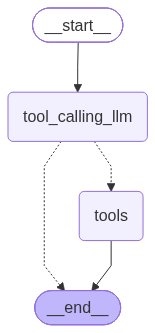

In [72]:
### Node definition
def tool_calling_llm(state: State):
    # Implement the logic for calling the LLM tool here
    return{"messages":llm_with_tools.invoke(state["messages"])}

# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# If the tool condition is met, proceed to the tools node--> tools_condition routes to the tools node
# If the latest message from aasitant is not a tool call --> tools_condition routes to the end node
tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()
# View 

display(Image(graph.get_graph().draw_mermaid_png()))

In [73]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  academic_search (call-0b7d5edf-7b67-44f3-88e2-1c058b9c95ef)
 Call ID: call-0b7d5edf-7b67-44f3-88e2-1c058b9c95ef
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: academic_search

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and c

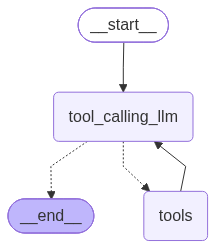

In [74]:
### Node definition
def tool_calling_llm(state: State):
    # Implement the logic for calling the LLM tool here
    return{"messages":llm_with_tools.invoke(state["messages"])}

# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# If the tool condition is met, proceed to the tools node--> tools_condition routes to the tools node
# If the latest message from aasitant is not a tool call --> tools_condition routes to the end node
tools_condition)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()
# View 

display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({"messages": HumanMessage(content="Hi my name is Kanad, please tell me about the latest research on quantum computing")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Kanad, please tell me about the latest research on quantum computing
================================== Ai Message ==================================
Tool Calls:
  academic_search (call-d8cb344b-e038-47d1-b276-983dd36d18d7)
 Call ID: call-d8cb344b-e038-47d1-b276-983dd36d18d7
  Args:
    query: latest research on quantum computing
================================= Tool Message =================================
Name: academic_search

Published: 2025-04-07
Title: Quantum Computing: Vision and Challenges
Authors: Sukhpal Singh Gill, Oktay Cetinkaya, Stefano Marrone, Daniel Claudino, David Haunschild, Leon Schlote, Huaming Wu, Carlo Ottaviani, Xiaoyuan Liu, Sree Pragna Machupalli, Kamalpreet Kaur, Priyansh Arora, Ji Liu, Ahmed Farouk, Houbing Herbert Song, Steve Uhlig, Kotagiri Ramamohanarao
Summary: The recent development of quantum computing, which uses entanglement, superposition, and other qu

## Adding Memory to the agentic Graph


In [76]:
response=graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I cannot find a function in the provided library that directly answers the question "What is my name?". However, I can suggest that you might be asking for information about yourself, which could be related to a web search. 

If you would like to search the web for your name, you could use the "web_search" function. 

Here is a possible function call:

 

Please replace "your name" with your actual name.
Tool Calls:
  web_search (call-248fbbc0-7eea-42ed-b25f-d4abe01aa449)
 Call ID: call-248fbbc0-7eea-42ed-b25f-d4abe01aa449
  Args:
    query: your name
================================= Tool Message =================================
Name: web_search

{"query": "your name", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://gkids.com/films/your-name", "title": "Your Name. - 

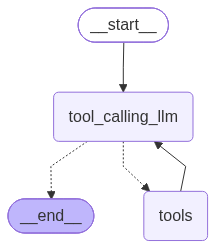

In [77]:
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
system_message = SystemMessage(
    content=(
        "You are a helpful conversational assistant. Answer greetings, introductions, "
        "and questions about information already stated in this conversation directly."
    )
)


def should_answer_directly(messages: list[AnyMessage]) -> bool:
    latest_message = messages[-1].content.lower()
    direct_phrases = (
        "hi", "hello", "hey", "my name is", "call me", "what is my name",
        "who am i", "thank you", "thanks",
    )
    return any(phrase in latest_message for phrase in direct_phrases)


def tool_calling_llm(state: State):
    messages = [system_message, *state["messages"]]
    model = llm if should_answer_directly(state["messages"]) else llm_with_tools
    return {"messages": model.invoke(messages)}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [78]:
config = {"configurable": {"thread_id": "kanad-demo"}}
response = graph.invoke({"messages": "Hi my name is Kanad"}, config=config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi my name is Kanad
================================== Ai Message ==================================

Nice to meet you, Kanad. How are you today?


In [79]:
response = graph.invoke({"messages": "What is my name?"}, config=config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi my name is Kanad
================================== Ai Message ==================================

Nice to meet you, Kanad. How are you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Kanad.


In [80]:
response=graph.invoke({"messages":"Give me the latest AI news and then multiply 5 by 10"},config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Kanad
================================== Ai Message ==================================

Nice to meet you, Kanad. How are you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Kanad.
================================ Human Message =================================

Give me the latest AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  web_search (call-e4e70188-89ba-46e6-8715-3b26589f8758)
 Call ID: call-e4e70188-89ba-46e6-8715-3b26589f8758
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: web_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"

## Streaming

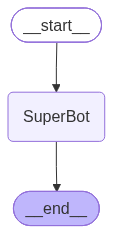

In [84]:
import IPython
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph = StateGraph(State)

# Add node



def superbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}
graph.add_node("SuperBot",superbot)

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display the graph
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [85]:
## Invocation

config={"configurable":{"thread_id":"kanad-demo"}}
graph_builder.invoke({"messages":"Hi, My name is Kanad"},config=config)

{'messages': [HumanMessage(content='Hi, My name is Kanad', additional_kwargs={}, response_metadata={}, id='7721c356-0a19-4366-bf78-1853a8ba5c29'),
  AIMessage(content='Nice to meet you, Kanad. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'content': 'Nice to meet you, Kanad. Is there something I can help you with or would you like to chat?', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 42, 'completion_tokens': 24, 'total_tokens': 66, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a03293-678d-72e3-beba-75d92167ff7b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 24, 'total_tokens': 66}, role='assistant')]}

## Streaming methods
### Methods: .stream() and astream()

    #### These methods are used to stream the output of the graph in real-time. They can be used in a synchronous or asynchronous manner.
### Additional parameters in streaming modes for state graphs:

    #### 1. values: This streams the full state of the graph after each node is called.
    #### 2. updates: This streams only the updates to the state of the graph after each node is called.

In [87]:
# create a thread
config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Kanad"},config=config, streaming_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Kanad. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'content': 'Nice to meet you, Kanad. Is there something I can help you with or would you like to chat?', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 42, 'completion_tokens': 24, 'total_tokens': 66, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a03299-12d4-7661-842b-e612405feeb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 24, 'total_tokens': 66}, role='assistant')]}}


In [88]:
# create a thread
config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Kanad"},config=config, streaming_mode="values"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Kanad, it's nice to meet you. How's your day going so far?", additional_kwargs={}, response_metadata={'content': "Hello Kanad, it's nice to meet you. How's your day going so far?", 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 82, 'completion_tokens': 20, 'total_tokens': 102, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a0329a-79f4-7a21-8bf4-ad7bf98bed9d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 82, 'output_tokens': 20, 'total_tokens': 102}, role='assistant')]}}


In [89]:
# create a thread
config={"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Kanad, I like MMA"},config=config, streaming_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Kanad. MMA (Mixed Martial Arts) is an exciting and physically demanding sport. Which fighters or weight classes do you enjoy watching the most? Are you a fan of any particular promotion, such as the UFC, Bellator, or ONE Championship?', additional_kwargs={}, response_metadata={'content': 'Nice to meet you, Kanad. MMA (Mixed Martial Arts) is an exciting and physically demanding sport. Which fighters or weight classes do you enjoy watching the most? Are you a fan of any particular promotion, such as the UFC, Bellator, or ONE Championship?', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 46, 'completion_tokens': 56, 'total_tokens': 102, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a0329b-7aa9-7901-80d1-d1cec9fdf7b2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [90]:
for chunk in graph_builder.stream({"messages":"Hi, My name is Kanad, I like MMA"},config=config, streaming_mode="values"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Kanad. MMA is a thrilling sport with a lot of action and skill.  Do you have a favorite MMA fighter or one that you like to watch?', additional_kwargs={}, response_metadata={'content': 'Hello Kanad. MMA is a thrilling sport with a lot of action and skill.  Do you have a favorite MMA fighter or one that you like to watch?', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 122, 'completion_tokens': 34, 'total_tokens': 156, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a0329b-de6d-7c92-b1da-49082cb59107-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 122, 'output_tokens': 34, 'total_tokens': 156}, role='assistant')]}}


In [92]:
config = {"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream({"messages":"Hi, My name is Kanad, I like MMA"},config=config, streaming_mode="values"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='Hi Kanad, nice to meet you. MMA is an exciting sport with a lot of talented fighters. Do you have a favorite MMA fighter, past or present?', additional_kwargs={}, response_metadata={'content': 'Hi Kanad, nice to meet you. MMA is an exciting sport with a lot of talented fighters. Do you have a favorite MMA fighter, past or present?', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 107, 'completion_tokens': 34, 'total_tokens': 141, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 16}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a0329d-d480-7811-b2fe-21d47fe2e4fb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 107, 'output_tokens': 34, 'total_tokens': 141}, role='assistant')]}}
